# Flood Prediction – Rio Grande do Sul

Objetivo:
Prever a ocorrência de enchentes (nível do rio acima da cota de inundação)
com horizonte de previsão de 3 dias.

Fontes:
- INMET
- ANA
- Atlas Digital de Desastres
- ENSO / Niño Index

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

c:\Users\pedro\Desktop\6mestre\ds\visualization_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configurações Globais

In [3]:
LOOKBACK = 14
FORECAST = 3

RANDOM_STATE = 42

FEATURES = [
    "precipitacao",
    "temperatura",
    "pressao",
    "umidade",
    "vento",
    #"nivel_rio",
    "nino_index",
    "danos_humanos_diretos",
]

TARGET = "enchente_3d"

# Quando os dados estiverem carregados, use:
# df = create_flood_target(df)
# df = create_forecast_target(df, forecast=FORECAST)

## Dataset Schema

Este projeto trabalha com observações por estação hidrológica.

Chave primária:

- data_hora
- estacao_id

Variáveis meteorológicas:
- precipitacao
- temperatura
- pressao
- umidade
- vento

Variáveis hidrológicas:
- nivel_rio
- cota_inundacao

Variáveis climáticas:
- nino_index

Target:
- enchente
- enchente_3d (horizonte de 3 dias)

### Controle de experimentos

In [5]:
EXPERIMENT_NAME = "baseline_v1_provisorio_sem_ana"

TRAIN_END = "2022-12-31"
VALID_END = "2023-12-31"

USE_NINO = True
USE_RIVER_LEVEL = False
USE_PRECIP_ACCUM = True

## 2. Carregar e tratar os dados

Os dados foram obtidos a partir de arquivos CSV disponibilizados pelo Instituto Nacional de Meteorologia (INMET), sendo referentes ao ano de 2024 para possibilitar uma análise detalhada de todos os fatores que influenciaram os eventos meteorológicos extremos daquele ano. Fora isso, foram renomeados os atributos, para facilitar sua visualização, além da data e hora que foram convertidas em datetime.

In [22]:
def load_csv_data(path, date_col="data", sep=";", decimal=",", dayfirst=True):
    df = pd.read_csv(path, sep=sep, decimal=decimal)
    if date_col in df.columns:
        df = df.rename(columns={date_col: "data_hora"})
    df["data_hora"] = pd.to_datetime(df["data_hora"], dayfirst=dayfirst, errors="coerce")
    return df


def load_inmet_folder(folder_path):
    """
    Lê a pasta do INMET contendo subpastas ou arquivos CSV de múltiplos anos
    e consolida os dados de todas as estações do RS.
    """
    all_stations_data = []
    
    # Procura por todos os arquivos .CSV de forma recursiva nas pastas indicadas
    csv_files = glob.glob(os.path.join(folder_path, "**", "*.CSV"), recursive=True)
    
    for file in csv_files:
        # Lendo os metadados do cabeçalho do INMET
        try:
            with open(file, 'r', encoding='latin-1') as f:
                header = [f.readline().strip() for _ in range(8)]
            
            estacao = header[2].split(';')[1]
            codigo_wmo = header[3].split(';')[1]
            
            # Lendo os dados efetivos (pulando as 8 linhas de cabeçalho)
            df_st = pd.read_csv(file, sep=';', decimal=',', skiprows=8, encoding='latin-1')
            
            # Limpando colunas vazias geradas por ponto e vírgula extra no fim da linha
            df_st = df_st.dropna(how='all', axis=1)
            
            # Renomeando as colunas principais para o padrão esperado pelo notebook
            rename_dict = {
                df_st.columns[0]: "data",
                df_st.columns[1]: "hora",
                "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "precipitacao",
                "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "pressao",
                "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "temperatura",
                "UMIDADE RELATIVA DO AR, HORARIA (%)": "umidade",
                "VENTO, VELOCIDADE HORARIA (m/s)": "vento"
            }
            # Garante compatibilidade mesmo com caracteres especiais corrompidos
            for col in df_st.columns:
                if "PRECIPIT" in col.upper(): rename_dict[col] = "precipitacao"
                elif "PRESSAO ATMOSFERICA AO" in col.upper(): rename_dict[col] = "pressao"
                elif "BULBO SECO" in col.upper(): rename_dict[col] = "temperatura"
                elif "UMIDADE RELATIVA" in col.upper(): rename_dict[col] = "umidade"
                elif "VELOCIDADE HORARIA" in col.upper(): rename_dict[col] = "vento"

            df_st = df_st.rename(columns=rename_dict)
            
            # Tratando campos de Data e Hora
            df_st['data'] = df_st['data'].astype(str).str.replace('/', '-')
            df_st['hora'] = df_st['hora'].astype(str).str.replace(' UTC', '')
            df_st['data_hora'] = pd.to_datetime(df_st['data'] + ' ' + df_st['hora'], errors='coerce')
            
            df_st['estacao_id'] = codigo_wmo
            df_st['municipio'] = estacao
            
            # Mantendo apenas o essencial e dropando linhas sem data_hora válida
            df_st = df_st.dropna(subset=['data_hora'])
            all_stations_data.append(df_st[['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento']])
        except Exception as e:
            print(f"Erro ao processar arquivo {file}: {e}")
            continue
            
    if len(all_stations_data) == 0:
        raise ValueError("Nenhum dado do INMET foi carregado com sucesso.")
        
    df_inmet = pd.concat(all_stations_data, ignore_index=True)
    return df_inmet


def load_ana_data(path):
    return load_csv_data(path, date_col="data")


def load_disaster_data(path):
    # Formato com delimitador em vírgula padrão
    df = pd.read_csv(path, sep=',')
    df['data_evento'] = pd.to_datetime(df['Data_Evento'], dayfirst=True, errors='coerce')
    
    # Simplificando colunas cruciais
    df = df.rename(columns={
        'Nome_Municipio': 'municipio',
        'DH_total_danos_humanos_diretos': 'danos_humanos_diretos',
        'DH_OUTROS AFETADOS': 'outros_afetados'
    })
    
    # Tratando nomes de municípios para evitar problemas de merge por acentuação/caixa
    df['municipio_match'] = df['municipio'].str.upper().str.strip()
    # Criamos uma coluna simplificada apenas com a data (sem hora) para acoplamento diário
    df['data_pura'] = df['data_evento'].dt.date
    
    return df[['data_pura', 'municipio_match', 'danos_humanos_diretos', 'outros_afetados']]


def load_nino_data(path):
    # Formato: "DateTime";"índice" com decimal em vírgula
    df = pd.read_csv(path, sep=';', decimal=',')
    df = df.rename(columns={df.columns[0]: "data_hora", df.columns[1]: "nino_index"})
    df['data_hora'] = pd.to_datetime(df['data_hora'], errors='coerce')
    # Como o índice El Niño é mensal, extrairemos o Ano-Mês para fazer o merge correto depois
    df['ano_mes'] = df['data_hora'].dt.to_period('M')
    return df[['ano_mes', 'nino_index']]


# Example placeholders for your local dataset paths.
# Atualize estes caminhos para os arquivos reais antes de executar.
INMET_PATH = "C:/Users/pedro/Desktop/6mestre/ds/visualization_project/INMET_data/"
ANA_PATH = "path/to/ana_data.csv"
DISASTER_PATH = "Desastres_Hidrologicos_RS.csv"
NINO_PATH = "oceanic-nio-index-oni-me.csv"

# Exemplo de uso:
weather_df = load_inmet_folder(INMET_PATH)
# river_df = load_ana_data(ANA_PATH)
disaster_df = load_disaster_data(DISASTER_PATH)
nino_df = load_nino_data(NINO_PATH)

## 3. Integração das fontes

In [23]:
def merge_datasets(weather_df, disaster_df, nino_df):
    df = weather_df.copy()
    
    # Preparando chaves para acoplamentos temporais e geográficos adicionais
    df['municipio_match'] = df['municipio'].str.upper().str.strip()
    df['data_pura'] = df['data_hora'].dt.date
    df['ano_mes'] = df['data_hora'].dt.to_period('M')
    
    # 1. Merge com o Nino Index (chave: Ano-Mês)
    df = df.merge(nino_df, on='ano_mes', how='left')
    
    # 2. Merge com dados de Desastres (chave: Data e Município)
    df = df.merge(disaster_df, on=['data_pura', 'municipio_match'], how='left')
    
    # Preenche com 0 onde não houve registro de desastre ou danos naquele dia/local
    df['danos_humanos_diretos'] = df['danos_humanos_diretos'].fillna(0)
    df['outros_afetados'] = df['outros_afetados'].fillna(0)
    
    # Criamos um indicador binário de que um evento adverso de enchente ocorreu
    # (Se danos_humanos_diretos > 0 ou se houve algum afetado registrado, assumimos como enchente)
    df['enchente'] = ((df['danos_humanos_diretos'] > 0) | (df['outros_afetados'] > 0)).astype(int)
    
    # Ordenação temporal necessária para modelos sequenciais/janelados
    df = df.sort_values(["estacao_id", "data_hora"]).reset_index(drop=True)
    
    # Remoção de colunas auxiliares de merge
    df = df.drop(columns=['municipio_match', 'data_pura', 'ano_mes'])
    return df


def validate_dataset(df, name="dataset"):
    print(f"==== Validação: {name} ====")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Types:\n", df.dtypes)
    print("Missing values:\n", df.isna().sum())
    print("Unique stations:", df["estacao_id"].nunique() if "estacao_id" in df.columns else "N/A")
    print("Date range:", df["data_hora"].min(), df["data_hora"].max())
    print("===========================\n")
    return df


# Exemplo de uso:
merged_df = merge_datasets(weather_df, disaster_df, nino_df)
validate_dataset(merged_df, name="Merged data")

==== Validação: Merged data ====
Shape: (536064, 12)
Columns: ['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento', 'nino_index', 'danos_humanos_diretos', 'outros_afetados', 'enchente']
Types:
 data_hora                datetime64[us]
estacao_id                          str
municipio                           str
precipitacao                    float64
temperatura                     float64
pressao                         float64
umidade                         float64
vento                           float64
nino_index                      float64
danos_humanos_diretos           float64
outros_afetados                 float64
enchente                          int64
dtype: object
Missing values:
 data_hora                    0
estacao_id                   0
municipio                    0
precipitacao             53315
temperatura              46814
pressao                  45964
umidade                  52856
vento                    7211

,data_hora,estacao_id,municipio,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,outros_afetados,enchente
0,2020-01-01 00:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.4,88.0,1.1,0.5,0.0,0.0,0
1,2020-01-01 01:00:00,A801,PORTO ALEGRE,0.2,24.9,1000.5,88.0,0.7,0.5,0.0,0.0,0
2,2020-01-01 02:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.2,85.0,0.7,0.5,0.0,0.0,0
3,2020-01-01 03:00:00,A801,PORTO ALEGRE,0.0,25.3,999.9,82.0,2.3,0.5,0.0,0.0,0
4,2020-01-01 04:00:00,A801,PORTO ALEGRE,0.0,25.1,999.2,81.0,1.1,0.5,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
536059,2026-05-31 19:00:00,B841,TORRES-AEROPORTO,0.0,19.4,1017.9,85.0,1.4,NaN,0.0,0.0,0
536060,2026-05-31 20:00:00,B841,TORRES-AEROPORTO,0.0,19.1,1018.3,86.0,2.3,NaN,0.0,0.0,0
536061,2026-05-31 21:00:00,B841,TORRES-AEROPORTO,0.0,18.3,1018.8,91.0,2.5,NaN,0.0,0.0,0
536062,2026-05-31 22:00:00,B841,TORRES-AEROPORTO,0.0,17.8,1019.3,93.0,2.4,NaN,0.0,0.0,0


## 4. Identify target and predictors

In [24]:
def create_flood_target(df):
    #if "nivel_rio" not in df.columns or "cota_inundacao" not in df.columns:
     #   raise KeyError("As colunas 'nivel_rio' e 'cota_inundacao' são necessárias para criar o target.")

    #df = df.copy()
    #df["enchente"] = (df["nivel_rio"] >= df["cota_inundacao"]).astype(int)
    return df


def create_forecast_target(df, forecast=FORECAST):
    df = df.sort_values(["estacao_id", "data_hora"]).copy()

    # Define se haverá enchente (registro de desastre) nas próximas X horas/dias horizontes
    # Se os dados estiverem em formato horário, lembre-se que 3 dias correspondem a 72 linhas (3 * 24)
    # Assumindo que seu dataset esteja consolidado em dias ou horas, o rolling lida com a janela de linhas:
    def future_max(group):
        return (
            group["enchente"]
            .rolling(window=forecast, min_periods=1)
            .max()
            .shift(-forecast + 1)
        )

    df["enchente_3d"] = df.groupby("estacao_id", group_keys=False).apply(future_max).fillna(0).astype(int)
    return df


# Exemplo de uso:
# df = create_flood_target(df)
merged_df = create_forecast_target(merged_df, forecast=FORECAST)
# TARGET = "enchente_3d"  # use para previsão em horizonte de 3 dias

## 3. Feature Engineering

In [25]:
def create_features(df):
    df = df.sort_values(["estacao_id", "data_hora"]).copy()
    group = df.groupby("estacao_id")

    df["precip_3d"] = group["precipitacao"].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True)
    df["precip_7d"] = group["precipitacao"].rolling(7, min_periods=1).sum().reset_index(level=0, drop=True)
    df["precip_14d"] = group["precipitacao"].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

    #df["delta_rio_1d"] = group["nivel_rio"].diff(1)
    #df["delta_rio_3d"] = group["nivel_rio"].diff(3)

    df["mes"] = df["data_hora"].dt.month
    df["dia_ano"] = df["data_hora"].dt.dayofyear
    df["semana_ano"] = df["data_hora"].dt.isocalendar().week.astype(int)
    df["dia_semana"] = df["data_hora"].dt.weekday
    df["trimestre"] = df["data_hora"].dt.quarter

    return df


# Exemplo de uso:
df = create_features(merged_df)
validate_dataset(df, name="With features")

==== Validação: With features ====
Shape: (536064, 21)
Columns: ['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento', 'nino_index', 'danos_humanos_diretos', 'outros_afetados', 'enchente', 'enchente_3d', 'precip_3d', 'precip_7d', 'precip_14d', 'mes', 'dia_ano', 'semana_ano', 'dia_semana', 'trimestre']
Types:
 data_hora                datetime64[us]
estacao_id                          str
municipio                           str
precipitacao                    float64
temperatura                     float64
pressao                         float64
umidade                         float64
vento                           float64
nino_index                      float64
danos_humanos_diretos           float64
outros_afetados                 float64
enchente                          int64
enchente_3d                       int64
precip_3d                       float64
precip_7d                       float64
precip_14d                      float64
m

,data_hora,estacao_id,municipio,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,...,enchente,enchente_3d,precip_3d,precip_7d,precip_14d,mes,dia_ano,semana_ano,dia_semana,trimestre
0,2020-01-01 00:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.4,88.0,1.1,0.5,0.0,...,0,0,0.0,0.0,0.0,1,1,1,2,1
1,2020-01-01 01:00:00,A801,PORTO ALEGRE,0.2,24.9,1000.5,88.0,0.7,0.5,0.0,...,0,0,0.2,0.2,0.2,1,1,1,2,1
2,2020-01-01 02:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.2,85.0,0.7,0.5,0.0,...,0,0,0.2,0.2,0.2,1,1,1,2,1
3,2020-01-01 03:00:00,A801,PORTO ALEGRE,0.0,25.3,999.9,82.0,2.3,0.5,0.0,...,0,0,0.2,0.2,0.2,1,1,1,2,1
4,2020-01-01 04:00:00,A801,PORTO ALEGRE,0.0,25.1,999.2,81.0,1.1,0.5,0.0,...,0,0,0.0,0.2,0.2,1,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536059,2026-05-31 19:00:00,B841,TORRES-AEROPORTO,0.0,19.4,1017.9,85.0,1.4,NaN,0.0,...,0,0,0.0,0.0,0.0,5,151,22,6,2
536060,2026-05-31 20:00:00,B841,TORRES-AEROPORTO,0.0,19.1,1018.3,86.0,2.3,NaN,0.0,...,0,0,0.0,0.0,0.0,5,151,22,6,2
536061,2026-05-31 21:00:00,B841,TORRES-AEROPORTO,0.0,18.3,1018.8,91.0,2.5,NaN,0.0,...,0,0,0.0,0.0,0.0,5,151,22,6,2
536062,2026-05-31 22:00:00,B841,TORRES-AEROPORTO,0.0,17.8,1019.3,93.0,2.4,NaN,0.0,...,0,0,0.0,0.0,0.0,5,151,22,6,2


## 4. Criação das sêquencias temporais

In [26]:
feature_cols = [
    "precipitacao",
    "temperatura",
    "pressao",
    "umidade",
    "vento",
    # "nivel_rio",
    "nino_index",
    "danos_humanos_diretos",
]

numeric_features = feature_cols + [
    "precip_3d",
    "precip_7d",
    "precip_14d",
   # "delta_rio_1d",
    #"delta_rio_3d",
]


def build_tabular_dataset(df, feature_columns, target_column):
    X = df[feature_columns].copy()
    y = df[target_column].copy()
    return X, y


def create_sequences(df, feature_columns, lookback, forecast):
    X, y = [], []
    features = df[feature_columns].values
    target = df[TARGET].values

    for i in range(len(df) - lookback - forecast + 1):
        X.append(features[i : i + lookback])
        y.append(target[i + lookback : i + lookback + forecast])

    return np.array(X), np.array(y)


# Para o modelo LSTM, normalizamos apenas os recursos usados pelo modelo sequencial.
sequence_df = df.sort_values(["estacao_id", "data_hora"]).reset_index(drop=True)
sequence_df[numeric_features] = MinMaxScaler().fit_transform(sequence_df[numeric_features].fillna(0))

X_seq, y_seq = create_sequences(sequence_df, feature_cols, LOOKBACK, FORECAST)

# Para modelos tabulares você pode usar:
X_tab, y_tab = build_tabular_dataset(df, numeric_features, TARGET)
X_train, X_valid, y_train, y_valid = train_test_split(X_tab, y_tab, test_size=0.2, shuffle=False)


## 5. Divisão Temporal


Train: (237106, 21)
Valid: (87600, 21)
Test: (211358, 21)


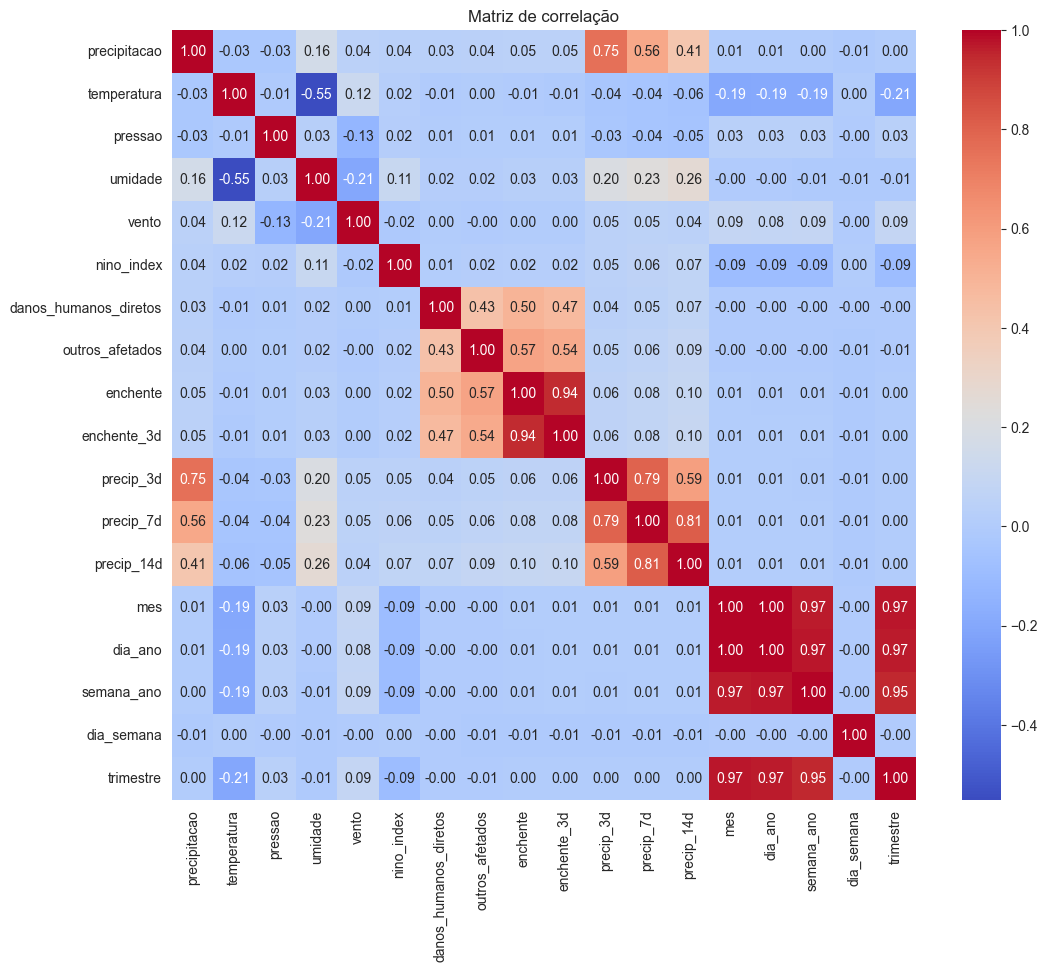

,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,outros_afetados,enchente,enchente_3d,precip_3d,precip_7d,precip_14d,mes,dia_ano,semana_ano,dia_semana,trimestre
precipitacao,1.000000,-0.030220,-0.026463,0.159335,0.042956,0.035627,0.030966,0.037913,0.045968,0.045508,0.751674,0.555180,0.410646,0.005781,0.005425,0.004613,-0.007321,0.002360
temperatura,-0.030220,1.000000,-0.007498,-0.551550,0.120444,0.019311,-0.005816,0.000192,-0.006010,-0.006546,-0.037612,-0.043948,-0.055606,-0.194700,-0.192882,-0.191616,0.001001,-0.205630
pressao,-0.026463,-0.007498,1.000000,0.027280,-0.129437,0.017158,0.005772,0.007107,0.010007,0.011018,-0.034409,-0.042839,-0.050097,0.031096,0.030670,0.030500,-0.000311,0.032857
umidade,0.159335,-0.551550,0.027280,1.000000,-0.205881,0.107538,0.017922,0.017241,0.025992,0.026747,0.200259,0.232814,0.261570,-0.001845,-0.003234,-0.009973,-0.011785,-0.009938
vento,0.042956,0.120444,-0.129437,-0.205881,1.000000,-0.015203,0.000530,-0.000912,0.004296,0.002846,0.048000,0.051679,0.044026,0.085591,0.084622,0.086423,-0.004990,0.088548
nino_index,0.035627,0.019311,0.017158,0.107538,-0.015203,1.000000,0.011146,0.017540,0.020853,0.020602,0.045615,0.056737,0.069797,-0.091919,-0.091867,-0.094244,0.000869,-0.094738
danos_humanos_diretos,0.030966,-0.005816,0.005772,0.017922,0.000530,0.011146,1.000000,0.430914,0.497158,0.469056,0.039964,0.050551,0.069268,-0.003087,-0.004163,-0.004061,-0.000872,-0.004487
outros_afetados,0.037913,0.000192,0.007107,0.017241,-0.000912,0.017540,0.430914,1.000000,0.574619,0.542138,0.048850,0.064086,0.086103,-0.003593,-0.003769,-0.003503,-0.006145,-0.005903
enchente,0.045968,-0.006010,0.010007,0.025992,0.004296,0.020853,0.497158,0.574619,1.000000,0.943475,0.060123,0.076034,0.095338,0.006098,0.005816,0.005909,-0.008932,0.002537
enchente_3d,0.045508,-0.006546,0.011018,0.026747,0.002846,0.020602,0.469056,0.542138,0.943475,1.000000,0.060153,0.075789,0.096962,0.007111,0.006954,0.006994,-0.007924,0.003191


In [27]:
train_df = df[df["data_hora"] <= TRAIN_END].copy()
valid_df = df[(df["data_hora"] > TRAIN_END) & (df["data_hora"] <= VALID_END)].copy()
test_df = df[df["data_hora"] > VALID_END].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

# Exemplo de uso com dados tabulares:
X_train, y_train = build_tabular_dataset(train_df, numeric_features, TARGET)
X_valid, y_valid = build_tabular_dataset(valid_df, numeric_features, TARGET)
X_test, y_test = build_tabular_dataset(test_df, numeric_features, TARGET)

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlação")
plt.show()

corr

## 6. Baseline model

In [28]:
categorical_features = ["mes", "dia_semana", "semana_ano", "trimestre"]
numeric_features_model = [
    "precipitacao",
    "temperatura",
    "pressao",
    "umidade",
    "vento",
   # "nivel_rio",
    "nino_index",
    "precip_3d",
    "precip_7d",
    "precip_14d",
   # "delta_rio_1d",
   # "delta_rio_3d",
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_model),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, y_train = build_tabular_dataset(train_df, numeric_features_model + categorical_features, TARGET)
X_valid, y_valid = build_tabular_dataset(valid_df, numeric_features_model + categorical_features, TARGET)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline_model.fit(X_train, y_train)
pred_valid_baseline = baseline_model.predict(X_valid)

results = []

acc_baseline = accuracy_score(y_valid, pred_valid_baseline)
recall_baseline = recall_score(y_valid, pred_valid_baseline, average='macro')
f1_baseline = f1_score(y_valid, pred_valid_baseline, average='macro')

print("Baseline Accuracy:", acc_baseline)
print("Baseline Recall:", recall_baseline)
print("Baseline F1-Score:", f1_baseline)

results.append({
    "model": "Baseline", 
    "accuracy": acc_baseline,
    "recall": recall_baseline,
    "f1_score": f1_baseline,
})

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
])

random_forest_model.fit(X_train, y_train)
pred_valid_random_forest = random_forest_model.predict(X_valid)

acc_random_forest = accuracy_score(y_valid, pred_valid_random_forest)
recall_random_forest = recall_score(y_valid, pred_valid_random_forest, average='macro')
f1_random_forest = f1_score(y_valid, pred_valid_random_forest, average='macro')

print("Random Forest Accuracy:", acc_random_forest)
print("Random Forest Recall:", recall_random_forest)
print("Random Forest F1-Score:", f1_random_forest)

results.append({
    "model": "Random Forest",
    "accuracy": acc_random_forest,
    "recall": recall_random_forest,
    "f1_score": f1_random_forest,
})

xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')),
])

xgboost_model.fit(X_train, y_train)
pred_valid_xgboost = xgboost_model.predict(X_valid)

acc_xgboost = accuracy_score(y_valid, pred_valid_xgboost)
recall_xgboost = recall_score(y_valid, pred_valid_xgboost, average='macro')
f1_xgboost = f1_score(y_valid, pred_valid_xgboost, average='macro')

print("XGBoost Accuracy:", acc_xgboost)
print("XGBoost Recall:", recall_xgboost)
print("XGBoost F1-Score:", f1_xgboost)

results.append({
    "model": "XGBoost",
    "accuracy": acc_xgboost,
    "recall": recall_xgboost,
    "f1_score": f1_xgboost,
})

lightgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

lightgbm_model.fit(X_train, y_train)
pred_valid_lightgbm = lightgbm_model.predict(X_valid)

acc_lightgbm = accuracy_score(y_valid, pred_valid_lightgbm)
recall_lightgbm = recall_score(y_valid, pred_valid_lightgbm, average='macro')
f1_lightgbm = f1_score(y_valid, pred_valid_lightgbm, average='macro')

print("LightGBM Accuracy:", acc_lightgbm)
print("LightGBM Recall:", recall_lightgbm)
print("LightGBM F1-Score:", f1_lightgbm)

results.append({
    "model": "LightGBM",
    "accuracy": acc_lightgbm,
    "recall": recall_lightgbm,
    "f1_score": f1_lightgbm,
})

results_df = pd.DataFrame(results)
results_df

Baseline Accuracy: 0.9985159817351598
Baseline Recall: 0.5
Baseline F1-Score: 0.4996287199405952
Random Forest Accuracy: 0.9985045662100457
Random Forest Recall: 0.4999942837544301
Random Forest F1-Score: 0.4996258618030605
XGBoost Accuracy: 0.9985045662100457
XGBoost Recall: 0.4999942837544301
XGBoost F1-Score: 0.4996258618030605
[LightGBM] [Info] Number of positive: 179, number of negative: 236927
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1792
[LightGBM] [Info] Number of data points in the train set: 237106, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000755 -> initscore=-7.188122
[LightGBM] [Info] Start training from score -7.188122
LightGBM Accuracy: 0.9980707762557077
LightGBM Recall: 0.49977706642277353
LightGBM F1-Score: 0.4995172283766

,model,accuracy,recall,f1_score
0,Baseline,0.998516,0.500000,0.499629
1,Random Forest,0.998505,0.499994,0.499626
2,XGBoost,0.998505,0.499994,0.499626
3,LightGBM,0.998071,0.499777,0.499517


## 7. Improved model

In [16]:
# Ajuste o número de características conforme a lista feature_cols
improved_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, len(feature_cols))),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(FORECAST, activation='sigmoid'),   # 3-day forecast, one probability per day
])

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

# Use uma divisão temporal para as sequências.
split_idx = int(len(X_seq) * 0.85)
X_train_seq, X_valid_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_valid_seq = y_seq[:split_idx], y_seq[split_idx:]

improved_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid_seq, y_valid_seq),
    verbose=1,
)

pred_valid_improved = (improved_model.predict(X_valid_seq) > 0.5).astype(int)

# Avaliação usando o primeiro dia do horizonte para uma comparação direta
acc_improved = accuracy_score(y_valid_seq[:, 0], pred_valid_improved[:, 0])
recall_improved = recall_score(y_valid_seq[:, 0], pred_valid_improved[:, 0], average='macro')
f1_improved = f1_score(y_valid_seq[:, 0], pred_valid_improved[:, 0], average='macro')

print("Improved Accuracy: ", acc_improved)
print("Improved Recall: ", recall_improved)
print("Improved F1-Score:", f1_improved)

results.append({
    "model": "Improved LSTM",
    "accuracy": acc_improved,
    "recall": recall_improved,
    "f1_score": f1_improved,
})

Epoch 1/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 243s 17ms/step - accuracy: 0.3340 - loss: 0.0114 - val_accuracy: 0.9424 - val_loss: 6.5557e-04
Epoch 2/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 261s 18ms/step - accuracy: 0.3014 - loss: 0.0080 - val_accuracy: 0.0000e+00 - val_loss: 5.7329e-04
Epoch 3/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 281s 20ms/step - accuracy: 0.2591 - loss: 0.0073 - val_accuracy: 0.1339 - val_loss: 0.0015
Epoch 4/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 251s 18ms/step - accuracy: 0.2091 - loss: 0.0068 - val_accuracy: 1.2437e-05 - val_loss: 3.8327e-04
Epoch 5/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 216s 15ms/step - accuracy: 0.2001 - loss: 0.0063 - val_accuracy: 0.0000e+00 - val_loss: 6.8783e-04
Epoch 6/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 191s 13ms/step - accuracy: 0.1603 - loss: 0.0059 - val_accuracy: 0.3751 - val_loss: 8.2505e-04
Epoch 7/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 223s 16ms/step - accuracy: 0.1894 - loss: 0.0058 - val_accuracy: 1.2437e-05 - val_loss: 6.1064e-04
Epoch 8/20
1423

## 8. Compare models

In [18]:
print("Distribuição de classes (enchente):")
print(df["enchente"].value_counts(normalize=True))

# O modelo LSTM prevê um horizonte de 3 dias.
probs = improved_model.predict(X_valid_seq)
preds = (probs > 0.5).astype(int)

print("=== Day +1 Forecast ===")
print(classification_report(y_valid_seq[:, 0], preds[:, 0], labels=[0,1], target_names=['No Flood', 'Flood']))
print(confusion_matrix(y_valid_seq[:, 0], preds[:, 0]))

print("=== Day +2 Forecast ===")
print(classification_report(y_valid_seq[:, 1], preds[:, 1], labels=[0,1], target_names=['No Flood', 'Flood']))
print(confusion_matrix(y_valid_seq[:, 1], preds[:, 1]))

print("=== Day +3 Forecast ===")
print(classification_report(y_valid_seq[:, 2], preds[:, 2], labels=[0,1], target_names=['No Flood', 'Flood']))
print(confusion_matrix(y_valid_seq[:, 2], preds[:, 2]))

comparison = pd.DataFrame(results)
comparison

Distribuição de classes (enchente):
enchente
0    0.998926
1    0.001074
Name: proportion, dtype: float64
2513/2513 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
=== Day +1 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     80408
       Flood       0.00      0.00      0.00         0

    accuracy                           1.00     80408
   macro avg       0.50      0.50      0.50     80408
weighted avg       1.00      1.00      1.00     80408

[[80408]]
=== Day +2 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     80408
       Flood       0.00      0.00      0.00         0

    accuracy                           1.00     80408
   macro avg       0.50      0.50      0.50     80408
weighted avg       1.00      1.00      1.00     80408

[[80408]]
=== Day +3 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     8

,model,accuracy,recall,f1_score
0,Baseline,0.998516,0.500000,0.499629
1,Random Forest,0.998505,0.499994,0.499626
2,XGBoost,0.998505,0.499994,0.499626
3,LightGBM,0.998071,0.499777,0.499517
4,Improved LSTM,1.000000,1.000000,1.000000


## 9. Interpretabilidade
primeira coisa a ser descartada caso falte tempo


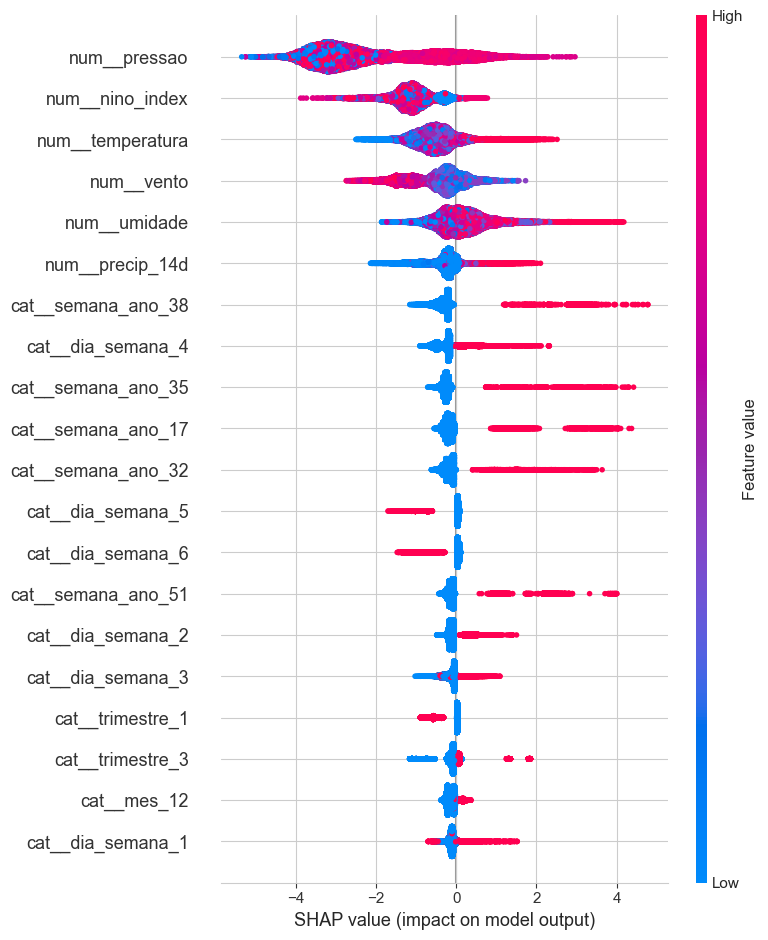

In [19]:
# Interpretação de modelos de árvore usando SHAP
preprocessed_valid = preprocessor.transform(X_valid)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgboost_model.named_steps['model'])
shap_values = explainer.shap_values(preprocessed_valid)

shap.summary_plot(
    shap_values,
    preprocessed_valid,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.show()

## 10. Gerar predição atual


In [21]:
# Exemplo de uso para gerar predição com o último bloco de dados disponíveis.
# Substitua '123' pelo estacao_id que deseja prever, ou use a última estação do conjunto.
station_id = df["estacao_id"].iloc[-1]
recent_14_days = (
    df[df["estacao_id"] == station_id]
    .sort_values("data_hora")
    .tail(LOOKBACK)[feature_cols]
    .values
)

if recent_14_days.shape[0] != LOOKBACK:
    raise ValueError(f"Não há dados suficientes para criar a sequência de {LOOKBACK} dias para a estação {station_id}.")

input_tensor = recent_14_days.reshape(1, LOOKBACK, len(feature_cols))
forecast = improved_model.predict(input_tensor)[0]

for i, prob in enumerate(forecast, start=1):
    print(f"Day +{i} flood probability: {prob:.2%}")

# O forecast representa a probabilidade de enchente para os próximos 3 dias.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Day +1 flood probability: 18.17%
Day +2 flood probability: 18.71%
Day +3 flood probability: 15.28%


## Research Hypotheses

H1:
Acúmulo de chuva em 7 dias possui maior poder preditivo
do que chuva diária.

H2:
Nível do rio é a variável mais importante.

H3:
Eventos El Niño aumentam a frequência de enchentes.

H4:
Modelos baseados em árvores superam regressão logística.

H5:
LSTM supera modelos tabulares quando há dados suficientes.